# БЫСТРОЕ ПРЕОБРАЗОВАНИЕ ФУРЬЕ

## Оличие ДПФ от БПФ
В случае действительного ДПФ N отсчётовдискретного сигнала, представленного во временной области, преобразуются в двамассива, по (N/2 + 1) 
отсчётов в каждом, частотной формы представления этогосигнала. Во временной области имеется одна последовательность дискретных от-счётов 
сигнала, а в частотной области сигнал состоит из двух частей — действитель-ной и мнимой. Отсчёты действительной части соответствуют 
амплитудам косинус-ных, а отсчёты мнимой части — амплитудам синусных компонентов разложения.После изучения предыдущих глав всё это должно 
быть вполне понятно.Комплексное ДПФ преобразует два массива длиной N отсчётов каждый, опи-сывающих сигнал во временной области, в два 
новых массива той же длины, опи-сывающих спектр сигнала в частотной области. В обеих парах один массив соот-ветствует действительной 
части, а другой — мнимой части сигнала. При этом вовсех четырёх массивах хранятся обычные действительные числа. 

Пусть имеется N отсчётов дискретного сигнала и требуется выполнить дейс-твительное ДПФ, используя для этой цели комплексное ДПФ, для 
вычислениякоторого можно воспользоваться алгоритмом БПФ. В этом случае **прежде всегоследует представить действительный входной сигнал как 
комплексный, разместить известные N отсчётов в массиве действительной части, а во все ячейки массива мнимой части записать нули**. 
Затем, выполнив комплексное ДПФ, мы полу-чим комплексный частотный спектр в виде массивов действительной и мнимойчастей длиной N отсчётов 
каждый. Первые (N/2 +1) отсчётов этих массивов со-ответствуют результату выполнения действительного ДПФ.
о

**ДПФ в экспоненциальной форме**

$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j\frac{2\pi kn}{N}} \quad \text{для } k = 0, 1, 2, \ldots, N-1$

В случае 8-точечного ДПФ следует, что необходимо выполнить $N^2$ , 
или 64, комплексных умножений.(Потому что для каждого из восьми отсчетов 
Хkт) мы должны просуммировать восемь комплексных произведений при изменени n
п от 0 д .7Количество комплексных умножений для N-точечного БПФ равно примерно 
$\frac{N}{2} \cdot \log_2 N$
«примерно», потому что некоторые умножения выполняются на +1 
или -1 и сводятся к простой перемене знака.).)


##  Как работает алгоритм БПФ

При обсуждении того, как работает алгоритм БПФ, используют терминологию комплексной математики.

**Что такое комплексное число?**

Комплексное число представляется в виде:

**z = a + bi**

где:
- **a** — действительная часть (Real)
- **b** — мнимая часть (Imaginary)
- **i** — мнимая единица, определяемая как **i² = -1**

**Операция умножения двух комплексных чисел**

Возьмем два комплексных числа:
- **z₁ = a + bi**
- **z₂ = c + di**

Их произведение будет равно:
**z₁ × z₂ = (a + bi) × (c + di)**

**1. Четыре операции умножения**

Мы раскрываем скобки, как в обычной алгебре (правило "каждый на каждый"):

- **a × c = ac**
- **a × di = adi**
- **bi × c = bci**
- **bi × di = bd × i²**

Итак, мы получили наши четыре произведения: **ac**, **adi**, **bci**, **bd × i²**

**2. Комбинирование произведений для получения двух компонентов**

Теперь мы комбинируем эти четыре произведения, чтобы снова получить одно число в стандартной форме **(действительная часть) + (мнимая часть)i**

**Шаг 1: Работа с i²**  
Мы помним фундаментальное свойство: **i² = -1**. Применяем его к четвертому произведению:  
**bd × i² = bd × (-1) = -bd**

**Шаг 2: Группировка действительных частей**  
Действительные числа у нас это **ac** и **-bd**. Складываем их:  
**Новая действительная часть = ac - bd**

**Шаг 3: Группировка мнимых частей**  
Мнимые части (члены с i) у нас это **adi** и **bci**. Складываем их:  
**adi + bci = (ad + bc)i**  
**Новая мнимая часть = ad + bc**

**Итоговая формула:**

**z₁ × z₂ = (a + bi)(c + di) = (ac - bd) + (ad + bc)i**.

**Выполнение алгоритма БПФ**

Выполнение алгоритма БПФ разбивается на три этапа. Сначала исходнаяпоследовательность, описывающая сигнал во временной области и состоящая из N отсчётов, разбивается на N отдельных сигналов, по одному отсчёту в каждом(декомпозиция). Следующий этап связан с переходом от N временных сигналов к N частотным спектрам. Завершается работа алгоритма синтезом единого спектрана основе полученных N спектров.

<img src="Splitting _decomposition_ of the FFT.jpg" alt="Преобразование прямоугольной в полярную систему координат." width="500" style="display: block; margin-right: 15px;">

**Вторым шагом выполнения БПФ, следующим за процедурой разбиения на N сигналов по одному отсчёту, является переход к спектрам этих сигналов.**

На этом шаге не нужно выполнять вообще никаких действий. Хотявторой шаг БПФ не требует проведения никаких программных операций, следует помнить, что каждый имеющийся отсчёт теперь становится отсчётом спектрасигнала и относится к частотной, а не к временной области.

**Последний шаг БПФ**

Последний шаг БПФ связан с объединением N спектров в порядке, в точнос-ти обратном тому, который использовался на первом шаге при разбиении исход-ного сигнала, представленного во временной области. Именно этот шаг алгорит-ма БПФ является самым сложным. К сожалению, применённую на первом шагеи упростившую все действия процедуру бит-реверсной сортировки теперь приме-нить не удастся и придётся последовательно пройти все этапы объединения от-счётов. На первом этапе 16 частотных спектров (по 1 отсчёту) группируются в 8спектров (по 2 отсчёта); на втором этапе полученные 8 спектров объединяются в 4спектра (по 4 отсчёта) и т. д. На последнем этапе должен получиться единствен-ный спектр, состоящий из 16 отсчётов, который и является искомым представле-нием исходного сигнала в частотной области, т. е. окончательным результатом ра-боты алгоритма БПФ.

Сначала производится дополнение каждого из двух сигналов нулями. При этомнули вводятся между первоначально имеющимися отсчётами, а число отсчётовувеличивается до 8. Затем соответствующие элементы сигналов складываются.Таким образом, сначала сигнал abed преобразуется в a0b0c0d0, а сигнал efgh — всигнал 0e0f0g0h; последующее поэлементное сложение двух сигналов даёт aebfcgdh. **Операция дополнения нулями во временной области соответствует повторению спектра в частотной области**. Следовательно, в алгоритме БПФ происходит объединение частотных спектров путём повторения и последующего по-элементного сложения.
Чтобы при сложении сигналов во временной области их отсчёты совместились,нули должны вводиться в эти сигналы по-разному: в первом — в нечётные элемен-ты, а во втором — в чётные. Поэтому один из сигналов сигнал OeOfOgOh оказывается смещённым по времени на один отсчёт вправо. Такой **сдвиг во временной области соответствует умножению на комплексную синусоиду в час-тотной области. Чтобы доказать данный факт, напомним, что сдвиг сигнала во вре-менной области эквивалентен свёртке этого сигнала со смещённой дискретной де-льта-функцией (единичным импульсом)**. *z₁ × z₂ = (a + bi)(c + di) = (ac - bd) + (ad + bc)i** × z₂ = (a + bi)(c + di) = (ac - bd) + (ad + bc)i**

**Советы**
- **Дискретизируйте достаточно часто и достаточно долго**

На практике в зависимости от приложения используют частоту дискретизации, которая в два с половиной — четыре раза превышае  
ширину спектра сигналаЕсли мы не знаем, какова ширина
спектра непрерывного сигнала, как нам определить, имеются ли наложения ил
нет? В этом случае нам следует с недоверием относиться к результатам БП ,
если имеются спектральные компоненты значительного уровня на частотах вбл зи
половины частоты дискретизации. В идеале нам хотелось бы работать с сигнал ми,
спектр которых убывает с ростом частоты. Будьте очень осторожны, ко да в
спектре обнаруживаются компоненты, частоты которых зависят от частоты дискрети ации.
Если у нас есть подозрение, что возникает наложение или что непр рывный
сигнал содержит широкополосный шум, необходимо п ред АЦЦ
включить аналоговый ФНЧ. Частота среза ФНЧ должна быть несколько выше мак имальной
интересующей нас частоты и ниже половины частоты диск

БПФ по основанию 2 тре^kбует N = 2 к входных отсчетов, 
сколько же именно отсчетов должны мы накопить для анализа Длительность интервала накопления данных является величиной, 
обратной требуемой разрешающей способности, и чем больше мы берем отсчетов  
фиксированной частотой д исетизациFs 5, тем выше разрешение по естоте; т.  .
общий интервал наен копля равN/Fs//5 секунд, а разрешающть апособноого ^-точечн г ПФ р Fs/Nх/Л^Гц. Следовательно, если нам необхющаяа разреша щая
сп Fs/N 5 Г Гц илицFs/N5 /ЛГ = 5 

**$N = \frac{F_s}{\text{требуемое разрешение}} = \frac{F_s}{5} = 0.2 и?ретизации..


## Советы

**Дискретизируйте достаточно часто и достаточно долго**

На практике в зависимости от приложения используют частоту дискретизации, которая в **два с половиной — четыре раза** превышает ширину спектра сигнала.

Если мы не знаем, какова ширина спектра непрерывного сигнала, как нам определить, имеются ли наложения или нет? В этом случае нам следует с недоверием относиться к результатам **БПФ**, если имеются спектральные компоненты значительного уровня на частотах **вблизи половины частоты дискретизации**. В идеале нам хотелось бы работать с сигналами, спектр которых убывает с ростом частоты. Будьте очень осторожны, когда в спектре обнаруживаются компоненты, частоты которых зависят от частоты дискретизации.

Если у нас есть подозрение, что возникает наложение или что непрерывный сигнал содержит широкополосный шум, необходимо **перед АЦП включить аналоговый ФНЧ**. Частота среза ФНЧ должна быть несколько выше максимальной интересующей нас частоты и ниже половины частоты дискретизации.

**Требования к количеству отсчетов для БПФ**

**БПФ по основанию 2** требует \( N = 2^k \) входных отсчетов.

Сколько же именно отсчетов должны мы накопить для анализа? Длительность интервала накопления данных является величиной, обратной требуемой разрешающей способности, и чем больше мы берем отсчетов фиксированной частотой дискретизации **F_s**, тем выше разрешение по частоте.

- Общий интервал накопления равен $( \frac{N}{F_s} )$ секунд
- Разрешающая способность **N** -точечного БПФ равна $\frac{F_s}{N}$ Гц

Следовательно, если нам необходима разрешающая способность 5 Гц:$\frac{F_s}{N} = 5$

$N = \frac{F_s}{\text{требуемое разрешение}} = \frac{F_s}{5} = 0.2 \cdot F_s$

В этом случае, если F_s равна, скажем, 10 кГц, то N должно быть не меньше 
2000, и нам придется взять N = 2048, потому что это ближайшее число, равное
целой степени. 2

# Разработка алгоритма БПФ по основанию 2

Этот и следующие разделы содержат подробное описание внутренних структур данных и операций БПФ по основанию 2 для тех читателей, которые интересуются разработкой программ БПФ или проектированием аппаратурных процессоров БПФ. Чтобы увидеть, как БПФ вырастает из ДПФ, напомним формулу $N$-точечного ДПФ:

$$X(m) = \sum_{n=0}^{N-1} x(n)e^{-j2\pi mn/N} \tag{4-11}$$

Простой и понятный способ получения алгоритма БПФ состоит в том, что исходная последовательность данных $x(n)$ делится на две части. Выделив отсчеты $x(n)$ с четными и нечетными индексами в две отдельные последовательности, мы можем разбить (4-11) на две части вида

$$X(m) = \sum_{n=0}^{(N/2)-1} x(2n)e^{-j2\pi(2n)m/N} + \sum_{n=0}^{(N/2)-1} x(2n+1)e^{-j2\pi(2n+1)m/N} \tag{4-12}$$

Вынося за знак второй суммы экспоненту с постоянным показателем степени, получаем

$$X(m) = \sum_{n=0}^{(N/2)-1} x(2n)e^{-j2\pi(2n)m/N} + e^{-j2\pi m/N} \sum_{n=0}^{(N/2)-1} x(2n+1)e^{-j2\pi(2n)m/N} \tag{4-13}$$

Для упрощения этих длинных и сложных выражений мы используем стандартные обозначения. Пусть $W_N = e^{-j2\pi/N}$ обозначает комплексный поворачивающий множитель, который постоянен для заданного $N$. Тогда (4-13) приобретает вид

$$X(m) = \sum_{n=0}^{(N/2)-1} x(2n)(W_N)^{2nm} + (W_N)^m \sum_{n=0}^{(N/2)-1} x(2n+1)(W_N)^{2nm} \tag{4-14}$$

Поскольку $(W_N)^2 = e^{-j2\pi(2/N)/N} = e^{-j2\pi/(N/2)}$, мы можем в формулу (4-14) подставить $W_{N/2}$ вместо $(W_N)^2$.

$$X(m) = \sum_{n=0}^{(N/2)-1} x(2n)(W_{N/2})^{nm} + (W_N)^m \sum_{n=0}^{(N/2)-1} x(2n+1)(W_{N/2})^{nm} \tag{4-15}$$

Итак, мы имеем две суммы $N/2$ слагаемых, результаты которых можно объединить в $N$-точечное ДПФ. В (4-15) мы сократили количество операций над данными по сравнению с (4-11), потому что множители $W$ в обеих суммах уравнения (4-15) идентичны. Дополнительный выигрыш от разбиения $N$-точечного ДПФ на две части мы получаем благодаря тому, что вторая половина отсчетов ДПФ вычисляется очень просто. Рассмотрим отсчет $X(m+N/2)$. Если мы подставим $m+N/2$ вместо $m$ в (4-15), то

$$X(m+N/2) = \sum_{n=0}^{(N/2)-1} x(2n)(W_{N/2})^{n(m+N/2)} + (W_N)^{(m+N/2)} \sum_{n=0}^{(N/2)-1} x(2n+1)(W_{N/2})^{n(m+N/2)} \tag{4-16}$$

Кажется, мы усложнили нашу задачу? Ничего, потерпите немного. Мы можем упростить поворачивающие множители под знаками сумм, потому что

$$(W_{N/2})^{n(m+N/2)} = (W_{N/2})^{nm}(W_{N/2})^{nN/2} = (W_{N/2})^{nm}(e^{-j2\pi nN/2N}) = (W_{N/2})^{nm}(1) = (W_{N/2})^{nm} \tag{4-17}$$

**Пояснение к формуле (4-17):**

Здесь используется важное равенство $e^{-j2\pi nN/2N} = e^{-j\pi n} = 1$ (для четных n), которое следует из формулы Эйлера и свойств комплексной экспоненты:

$$e^{j\theta} = \cos(\theta) + j\sin(\theta)$$

При $\theta = -2\pi nN/2N = -\pi n$:

$$e^{-j\pi n} = \cos(-\pi n) + j\sin(-\pi n) = \cos(\pi n) - j\sin(\pi n)$$

Для целых значений n:
- Когда n четное: $\cos(\pi n) = 1$, $\sin(\pi n) = 0$ ⇒ $e^{-j\pi n} = 1$
- Когда n нечетное: $\cos(\pi n) = -1$, $\sin(\pi n) = 0$ ⇒ $e^{-j\pi n} = -1$

Однако в контексте БПФ по основанию 2, где N является степенью двойки, и мы работаем с целыми степенями, это упрощение корректно работает для всех необходимых вычислений.

Внимательно проанализировав _поворачивающий множитель_ перед второй суммой в (4-16), мы можем упростить его как

$$(W_N)^{(m+N/2)} = (W_N)^m(W_N)^{N/2} = (W_N)^m(e^{-j2\pi N/2N}) = (W_N)^m(e^{-j\pi}) = (W_N)^m(-1) = -(W_N)^m \tag{4-18}$$

**Пояснение к формуле (4-18):**

Здесь используется важное равенство $e^{-j\pi} = -1$, которое следует из формулы Эйлера:

$$e^{j\theta} = \cos(\theta) + j\sin(\theta)$$

При $\theta = -\pi$:

$$e^{-j\pi} = \cos(-\pi) + j\sin(-\pi) = \cos(\pi) - j\sin(\pi) = -1 - j\cdot0 = -1$$

Это тождество фундаментально для понимания преобразований Фурье и широко используется в алгоритмах БПФ.

Далее, используя (4-17) и (4-18), мы представляем $X(m+N/2)$ из (4-16) как

$$X(m+N/2) = \sum_{n=0}^{(N/2)-1} x(2n)(W_{N/2})^{nm} - (W_N)^m \sum_{n=0}^{(N/2)-1} x(2n+1)(W_{N/2})^{nm} \tag{4-19}$$

Теперь повторим (4-15) и (4-19), чтобы увидеть, насколько они схожи:

$$X(m) = \sum_{n=0}^{(N/2)-1} x(2n)(W_{N/2})^{nm} + (W_N)^m \sum_{n=0}^{(N/2)-1} x(2n+1)(W_{N/2})^{nm} \tag{4-20}$$

$$X(m+N/2) = \sum_{n=0}^{(N/2)-1} x(2n)(W_{N/2})^{nm} - (W_N)^m \sum_{n=0}^{(N/2)-1} x(2n+1)(W_{N/2})^{nm} \tag{4-20'}$$

Ну вот, мы и получили то, что хотели. Для вычисления $X(m+N/2)$ нам не нужно выполнять никаких умножений на синусы и косинусы. Мы просто изменяем знак поворачивающего множителя $(W_N)^m$ и используем две суммы, полученные для $X(m)$, для вычисления $X(m+N/2)$. Конечно, в (4-20) $m$ принимает значения от 0 до $(N/2)-1$, а это значит, что для N-точечного ДПФ мы выполняем два $N/2$-точечных ДПФ, получая первые $N/2$ отсчетов, а затем используем уже полученные результаты для вычисления последних $N/2$ отсчетов. При $N = 8$ (4-20) и (4-20') реализуются так, как показано на рисунке 4.2.
Если мы запишем (4-20) и (4-20') в более простой форме:

$$X(m) = A(m) + (W_N)^m B(m), \tag{4-21}$$

и

$$X(m+N/2)=A(m)-(W_{N})^{m}B(m), \tag{4-21'}$$

мы можем пойти дальше и разбить два 4-точечных ДПФ на четыре 2-точечных ДПФ. Посмотрим, как можно разделить верхнее 4-точечное ДПФ на рисунке 4.2, четыре выхода которого равны $A(m)$ в (4-21) и (4-21'). 

![Рисунок 4.2 - Первый этап разбиения 8-точечного ДПФ](FFT_1.jpg)

Мы можем разделить четные и нечетные входные отсчеты верхнего 4-точечного ДПФ:

$$A(m)=\sum_{n=0}^{(N/2)-1}x(2n)(W_{N/2})^{nm}=$$

$$=\sum_{n=0}^{(N/4)-1}x(4n)(W_{N/2})^{2nm}+\sum_{n=0}^{(N/4)-1}x(4n+2)(W_{N/2})^{(2n+1)m}. \tag{4-22}$$

Поскольку $(W_{N/2})^{2nm} = (W_{N/4})^{nm}$, мы можем выразить $A(m)$ через два $N/4$-точечных ДПФ как

$$A(m)=\sum_{n=0}^{(N/4)-1}x(4n)(W_{N/4})^{nm}+(W_{N/2})^{m}\sum_{n=0}^{(N/4)-1}x(4n+2)(W_{N/4})^{nm}. \tag{4-23}$$

Обратите внимание на сходство выражений (4-23) и (4-20). Эта возможность деления $N/2$-точечного ДПФ на два $N/4$-точечных ДПФ и сообщает алгоритму БПФ способность существенно уменьшать количество необходимых умножений при реализации ДПФ. (Мы это вскоре продемонстрируем на примере.) Выполняя те же шаги, которые мы выполняли для получения $A(m)$, можно показать, что $B(m)$ в (4-21) имеет вид

$$B(m)=\sum_{n=0}^{(N/4)-1}x(4n+1)(W_{N/4})^{nm}+(W_{N/2})^{m}\sum_{n=0}^{(N/4)-1}x(4n+3)(W_{N/4})^{nm}. \tag{4-24}$$

При $N=8$ (4-23) и (4-24) реализуются так, как показано на рисунке 4.3. Здесь отчетливо видна структура сигнального графа, содержащая хорошо известные бабочки, и мы видим дальнейшую перетасовку входных данных.

![Рисунок 4.3 - Второй этап разбиения ДПФ](FFT_2.jpg)

Поворачивающий множитель $(W_{N/2})^{m}$ в (4-23) и (4-24) в нашем примере с $N=8$ изменяется от $(W_{N/2})^{0}$ до $(W_{N/4})^{0}$, потому что индекс $m$ для $A(m)$ и $B(m)$ изменяется от 0 до 3. Для любого $N$-точечного ДПФ мы можем разбить каждое из $N/2$-точечных ДПФ на два $N/4$-точечных ДПФ с целью дальнейшего уменьшения количества умножений на синусы и косинусы. В конце концов мы дойдем до ряда 2-точечных ДПФ, после чего дальнейшее сокращение количества операций уже невозможно. Именно по этой причине количество точек БПФ может быть равно только целой степени двойки, а этот алгоритм БПФ называется БПФ по основанию 2.

Двигаясь в том же направлении, сделаем еще один шаг вперед и закончим с рассматриваемым $N=8$-точечным ДПФ. Двухточечные ДПФ на рисунке 4.3 нельзя разделить на более мелкие части — мы дошли до конца в процессе уменьшения длины последовательности и пришли к бабочке одного 2-точечного ДПФ, показанной на рисунке 4.4.

![Рисунок 4.4 - Бабочка 2-точечного ДПФ](FFT_3.jpg)

Из определения $W_{N}$ следует, что $(W_{N})^{0} = e^{-j2\pi 0/N} = 1$, следовательно, блоки 2-точечного ДПФ на рисунке 4.3 можно заменить бабочкой, показанной на рисунке 4.4, получив, таким образом, полную реализацию 8-точечного БПФ, показанную на рисунке 4.5.

![Рисунок 4.5 - Полная реализация 8-точечного БПФ](FFT_4.jpg)

Проверка алгоритма БПФ на примере## Проверка алгоритма БПФ на примере

Итак, мы прошли через изрядное количество алгебраических манипуляций. Чтобы проверить правильность нашего вывода алгоритма БПФ, мы можем взять 8-точечную последовательность из примера 1 в главе 3 и обработать ее в соответствии с алгоритмом 8-точечного БПФ, представленным на рисунке 4.5. Последовательность данных, представляющая сигнал $x(n) = \sin(2\pi 1000nt_s) + 0.5\sin(2\pi 2000nt_s + 3\pi/4)$, имеет вид:

$$
\begin{aligned}
x(0) &= 0.3535, \quad &x(1) &= 0.3535, \\
x(2) &= 0.6464, \quad &x(3) &= 1.0607, \\
x(4) &= 0.3535, \quad &x(5) &= -1.0607, \\
x(6) &= -1.3535, \quad &x(7) &= -0.3535.
\end{aligned}
$$

### Пояснение к промежуточным вычислениям

После начальной перестановки и выполнения операций "бабочки" на первом каскаде БПФ, мы получаем промежуточные значения:

**Для последовательности $A(m)$ (четные индексы):**

$$
\begin{aligned}
0.707 &= x(0) + x(4) = 0.3535 + 0.3535 = 0.707 \\
-0.707 &= x(2) + x(6) = 0.6464 + (-1.3535) = -0.7071 \approx -0.707 \\
0.0 &= x(0) - x(4) = 0.3535 - 0.3535 = 0.0 \\
1.999 &= x(2) - x(6) = 0.6464 - (-1.3535) = 1.9999 \approx 1.999
\end{aligned}
$$

**Для последовательности $B(m)$ (нечетные индексы):**

$$
\begin{aligned}
-0.707 &= x(1) + x(5) = 0.3535 + (-1.0607) = -0.7072 \approx -0.707 \\
0.707 &= x(3) + x(7) = 1.0607 + (-0.3535) = 0.7072 \approx 0.707 \\
1.414 &= x(1) - x(5) = 0.3535 - (-1.0607) = 1.4142 \approx 1.414 \\
1.414 &= x(3) - x(7) = 1.0607 - (-0.3535) = 1.4142 \approx 1.414
\end{aligned}
$$

### Второй этап вычислений

На втором каскаде БПФ выполняются операции с поворачивающими множителями $W_4$:

$$
\begin{aligned}
W_4^0 &= 1, \\
W_4^1 &= e^{-j\pi/2} = -j, \\
W_4^2 &= e^{-j\pi} = -1, \\
W_4^3 &= e^{-j3\pi/2} = j,
\end{aligned}
$$

Начнем перетасовывать эти восемь точек, наложив входные значения на рисунок 4.5, в результате чего получим значения, показанные в левой части рисунка 4.6. Выходные значения второго каскада БПФ равны:

$$
\begin{aligned}
A(0) &= 0.707 + (W_4)^0(-0.707) = 0.707 + (1+j0)(-0.707) = 0+j0, \\
A(1) &= 0.0 + (W_4)^1(1.999) = 0.0 + (0-j1)(1.999) = 0-j1.999, \\
A(2) &= 0.707 + (W_4)^2(-0.707) = 0.707 + (-1+j0)(-0.707) = 1.414+j0, \\
A(3) &= 0.0 + (W_4)^3(1.999) = 0.0 + (0+j1)(1.999) = 0+j1.999, \\
B(0) &= 0.707 + (W_4)^0(0.707) = -0.707 + (1+j0)(0.707) = 0+j0, \\
B(1) &= 1.414 + (W_4)^1(1.414) = 1.414 + (0-j1)(1.414) = 1.414-j1.414, \\
B(2) &= -0.707 + (W_4)^2(0.707) = -0.707 + (-1+j0)(0.707) = -1.414+j0, \\
B(3) &= 1.414 + (W_4)^3(1.414) = 1.414 + (0+j1)(1.414) = 1.414+j1.414.
\end{aligned}
$$

### Результаты третьего каскада БПФ

Вычисляя результат третьего каскада БПФ, получаем окончательный ответ:

$$
\begin{aligned}
X(0) &= A(0) + (W_8)^0 B(0) = 0 + j0 + (1 + j0)(0 + j0) = 0 + j0 + 0 + j0 = 0 \angle 0^\circ, \\
X(1) &= A(1) + (W_8)^1 B(1) = 0 - j1.999 + (0.707 - j0.707)(1.414 - j1.414) = 0 - j1.999 + 0 - j1.999 = 0 - j4 = 4 \angle -90^\circ, \\
X(2) &= A(2) + (W_8)^2 B(2) = 1.414 + j0 + (0 - j1)(-1.414 + j0) = 1.414 + j0 + 0 + j1.414 = 1.414 + j1.414 = 2 \angle 45^\circ, \\
X(3) &= A(3) + (W_8)^3 B(3) = 0 + j1.999 + (-0.707 - j0.707)(1.414 + j1.414) = 0 + j1.999 + 0 - j1.999 = 0 \angle 0^\circ, \\
X(4) &= A(0) + (W_8)^4 B(0) = 0 + j0 + (-1 + j0)(0 + j0) = 0 + j0 + 0 + j0 = 0 \angle 0^\circ, \\
X(5) &= A(1) + (W_8)^5 B(1) = 0 - j1.999 + (-0.707 + j0.707)(1.414 - j1.414) = 0 - j1.999 + 0 + j1.999 = 0 \angle 0^\circ, \\
X(6) &= A(2) + (W_8)^6 B(2) = 1.414 + j0 + (0 + j1)(-1.414 + j0) = 1.414 + j0 + 0 + j1.414 = 1.414 - j1.414 = 2 \angle -45^\circ, \\
X(7) &= A(3) + (W_8)^7 B(3) = 0 + j1.999 + (0.707 + j0.707)(1.414 + j
### БИТ-реверсивная перестановка 
входных и выходных данных БП
ФРассмотрим некоторые особые свойства БПФ, которые имеют большое значение 
для разработчиков программ и аппаратурных процессоров БПФ. Заметим, что рисунок
4.5 назван «Полная реализация БПФ с прореживанием по времени для 8-точе -
ного ДПФ». Слова с прореживанием по времени относятся к способу разбиения
входной последовательности отсчетов на четные и нечетные, который мы использо али
при выводе соотношений (4-20), (4-23) и (4-24). Такое прореживание при одит
к перемешиванию входных отсчетов на рисунке 4.5. Принцип перемешивания можно
понять с помощью таблицы 4.1. Это перемешивание называют бит-ревер ивным,
потому что порядок следования отсчетов в перемешанной последоват льности
можно получить путем изменения порядка следования битов в двоичном пред тавлении
индексов отсчетов в неперемешанной последовательности наЭто звучит несколько запутанно, но на самом деле все просто — таблица 4.1 иллюстрирует 
реверс битов для рассматриваемого примера 8-точечного БПФ. Обратит 
внимание на то, что индексы в левом столбце таблицы 4.1 расположены в
нормальном порядке, а в правом столбце индексы приведены в перемешанном поряд е,
который совпадает с окончательным порядком следования прореже ных
входных отсчетов на рисунке 4.5. Мы перевернули биты двоичного представ ения
нормальных индексов, поменяв их порядок следования на обратный. С арший
бит стал младшим, а младший стал старшим, следующий за старшим б т стал
следующим за младшим, .и ![Рисунок 4.7 - Избыточность поворачивающих множителей для 8-точечного БПФ](FFT_5.jpg)
т. д.1

 обратный.
1.414) = 0 + j1.999 + 0 + j1.999 = 0 + j4 = 4 \angle 90^\circ.
\end{aligned}
$$

### Заключение

Итак, к счастью, БПФ дает правильный результат, и это позволяет нам снова напомнить читателю, что БПФ не является аппроксимацией ДПФ, а представляет собой ДПФ с уменьшенным количеством арифметических операций. В приведенном выше примере вы могли видеть, что вычисление 8-точечного БПФ требует меньших затрат, чем 8-точечное ДПФ из первого примера в разделе 3.1. Некоторые авторы предпочитают объяснять это уменьшение количества арифметических операций избыточностью поворачивающих множителей. Они показывают это с помощью _звездной диаграммы_, приведенной на рисунке 4.7, которая демонстрирует эквивалентность некоторых поворачивающих множителей в 8-точечном ДПФ.

Важные тождества $e^{-j\pi n} = 1$ для четных $n$ и $e^{-j\pi} = -1$ позволяют упростить вычисления. Вычисление второй половины отсчетов ДПФ требует только изменения знака перед уже вычисленными суммами.квивалентность некоторых поворачивающих множителей в 8-точечном ДПФ.99,веденной на рисунке 4.7, которая демонстрирует эквивалентность некоторых поворачивающих множителей в 8-точечном ДПФ.множителей в 8-точечном ДПФ.сть некоторых поворачивающих множителей в 8-точечном ДПФ.онстрирует эквивалентность некоторых поворачивающих множителей в 8-точечном ДПФ./N}$
3. Важные тождества $e^{-j\pi n} = 1$ (для четных n) и $e^{-j\pi} = -1$ позволяют упростить вычисления
4. Вычисление второй по -->ловины отсчетов ДПФ требует только изменения знака перед уже вычисленными суммами

##  Примеры программной реализации БПФ

In [ ]:
# Бит-реверсная сортировка
for I in range(1, ND2):
    if I >= J:
        pass
    else:
        TR = REX[J]
        TI = IMX[J]
        REX[J] = REX[I]
        IMX[J] = IMX[I]
        REX[I] = TR
        IMX[I] = TI
    
    K = ND2
    while K <= J:
        J = J - K
        K = K // 2
    J = J + K

# Цикл по уровням разложения
for L in range(1, M + 1):
    LE = int(2 ** L)
    LE2 = LE // 2
    UR = 1.0
    UI = 0.0
    SR = np.cos(PI / LE2)    # Вычисление отсчётов синуса и косинуса
    SI = -np.sin(PI / LE2)
    
    for J in range(0, LE2):   # Цикл по спектрам внутри уровня
        JM1 = J
        for I in range(JM1, NM1 + 1, LE):  # Цикл по отдельным «бабочкам»
            IP = I + LE2
            TR = REX[IP] * UR - IMX[IP] * UI  # Операция «бабочка»
            TI = REX[IP] * UI + IMX[IP] * UR
            REX[IP] = REX[I] - TR
            IMX[IP] = IMX[I] - TI
            REX[I] = REX[I] + TR
            IMX[I] = IMX[I] + TI
        
        TR = UR
        UR = TR * SR - UI * SI
        UI = TR * SI + UI * SR

return REX, IMX

In [ ]:
###-------------------------------------- Пример №2 --------------------------------------###

# Быстрое преобразование Фурье (БПФ)
# Реализация алгоритма БПФ на Python по образцу программы на Бейсике

import numpy as np
import matplotlib.pyplot as plt
from bokeh.layouts import column, gridplot
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
# Активируем вывод графиков в ноутбук
output_notebook()

# ----------------------------
# ПАРАМЕТРЫ СИГНАЛОВ
# ----------------------------

# Общее количество отсчетов для всех сигналов
N = 32  # Количество дискретных точек (отсчетов) для построения сигналов

# Амплитуды сигналов:
W1_A = 1.0  # Амплитуда дополнительной волны 1
W2_A = 1.0  # Амплитуда дополнительной волны 2
W3_A = 1.0  # Амплитуда дополнительной волны 3
W4_A = 1.0  # Амплитуда дополнительной волны 4

# Фазы сигналов в градусах:
W1_P_DEG = 0   # Фаза дополнительной волны 1
W2_P_DEG = 0   # Фаза дополнительной волны 2
W3_P_DEG = 0   # Фаза дополнительной волны 3
W4_P_DEG = 0   # Фаза дополнительной волны 4

# Количество периодов сигнала (K):
W1_K = 3.7  # Дополнительная волна 1
W2_K = 0  # Дополнительная волна 2
W3_K = 0  # Дополнительная волна 3
W4_K = 0  # Дополнительная волна 4

# ----------------------------
# ПОДГОТОВКА ДАННЫХ
# ----------------------------

# Создаем массив отсчетов (от 0 до N-1)
N_i = np.arange(N)  # [0, 1, 2, ..., N-1]

# Конвертация фаз из градусов в радианы (требуется для тригонометрических функций)
W1_P_RAD = W1_P_DEG * np.pi / 180 # Формула преобразования: радианы = градусы * π/180
W2_P_RAD = W2_P_DEG * np.pi / 180
W3_P_RAD = W3_P_DEG * np.pi / 180
W4_P_RAD = W4_P_DEG * np.pi / 180

# ----------------------------
# ГЕНЕРАЦИЯ СИГНАЛОВ
# ----------------------------

# Генерация синусоиды:
# Формула: A * sin(2π * K * n/N + φ)
#   K - количество периодов
#   n - текущий отсчет
#   N - общее количество отсчетов
#   φ - фаза в радианах

# Используем sin вместо cos, но с фазой, отличающейся на π/2
# (cos(x) = sin(x + π/2), но здесь фаза задается параметром)
# Генерация  волн:
wave_1 = W1_A * np.sin(2 * np.pi * W1_K * N_i / N + W1_P_RAD)
wave_2 = W2_A * np.sin(2 * np.pi * W2_K * N_i / N + W2_P_RAD)
wave_3 = W3_A * np.sin(2 * np.pi * W3_K * N_i / N + W3_P_RAD)
wave_4 = W4_A * np.sin(2 * np.pi * W4_K * N_i / N + W4_P_RAD)

# ----------------------------
# СУММИРОВАНИЕ СИГНАЛОВ
# ----------------------------

# Сумма сгенерированных сигналов, в зависимости от примера количество сигналов может быть больше или меньше.
sum_wave = wave_1 + wave_2 + wave_3 + wave_4

# ----------------------------
# БЫСТРОЕ ПРЕОБРАЗОВАНИЕ ФУРЬЕ (БПФ)
# ----------------------------

def fast_fourier_transform(N, REX, IMX):
    """
    Быстрое преобразование Фурье
    Порядок ДПФ N и массивы действительных и мнимых компонент REX[ ] и IMX[ ]
    заполняются до входа в подпрограмму. Выходные данные размещаются в 
    тех же массивах REX[ ] и IMX[ ]. Номера элементов массивов: 0…(N-1).
    """
    PI = 3.14159265      # Константа
    NM1 = N - 1
    ND2 = N // 2
    M = int(np.log(N) / np.log(2))
    J = ND2
    
    # Бит-реверсная сортировка
    for I in range(1, NM1):
        if I < J:
            TR = REX[J]
            TI = IMX[J]
            REX[J] = REX[I]
            IMX[J] = IMX[I]
            REX[I] = TR
            IMX[I] = TI
        
        K = ND2
        while K <= J:
            J = J - K
            K = K // 2
        J = J + K
    
    # Цикл по уровням разложения
    for L in range(1, M + 1):
        LE = int(2 ** L)
        LE2 = LE // 2
        UR = 1.0
        UI = 0.0
        SR = np.cos(PI / LE2)    # Вычисление отсчётов синуса и косинуса
        SI = -np.sin(PI / LE2)
        
        for J in range(0, LE2):   # Цикл по спектрам внутри уровня
            JM1 = J
            for I in range(JM1, NM1 + 1, LE):  # Цикл по отдельным «бабочкам»
                IP = I + LE2
                TR = REX[IP] * UR - IMX[IP] * UI  # Операция «бабочка»
                TI = REX[IP] * UI + IMX[IP] * UR
                REX[IP] = REX[I] - TR
                IMX[IP] = IMX[I] - TI
                REX[I] = REX[I] + TR
                IMX[I] = IMX[I] + TI
            
            TR = UR
            UR = TR * SR - UI * SI
            UI = TR * SI + UI * SR
    
    return REX, IMX

# Инициализация массивов для БПФ
REX = sum_wave.copy().astype(float)
IMX = np.zeros(N, dtype=float)

# Выполнение БПФ
REX, IMX = fast_fourier_transform(N, REX, IMX)

# Вычисление амплитудного и фазового спектров
MAG = np.sqrt(REX**2 + IMX**2)
PHASE = np.arctan2(IMX, REX)

# ----------------------------
# ВИЗУАЛИЗАЦИЯ
# ----------------------------

# Создаем массив для оси X (нулевая линия)
X_axis = np.zeros(N)

# 1. График исходного сигнала
p1 = figure(title="Исходный сигнал", width=800, height=300, x_axis_label='Отсчеты', y_axis_label='Амплитуда')
p1.scatter(N_i, sum_wave, size=7, marker="circle", legend_label="sum_wave", line_color="blue", fill_alpha=0.3)
p1.line(N_i, sum_wave, legend_label="sum_wave", line_color="blue")
p1.line(N_i, X_axis, line_color="black")

# 2. График амплитудного спектра (БПФ)
p2 = figure(title="Амплитудный спектр (БПФ)", width=800, height=300, x_axis_label='Частота', y_axis_label='Амплитуда')
p2.circle(N_i, MAG, size=8, color="red", alpha=0.7)
p2.segment(x0=N_i, y0=X_axis, x1=N_i, y1=MAG, color="red", alpha=0.6, line_width=2)

# 3. График фазового спектра (БПФ)
p3 = figure(title="Фазовый спектр (БПФ)", width=800, height=300, x_axis_label='Частота', y_axis_label='Фаза (рад)')
p3.circle(N_i, PHASE, size=8, color="purple", alpha=0.7)
p3.segment(x0=N_i, y0=X_axis, x1=N_i, y1=PHASE, color="purple", alpha=0.6, line_width=2)

# 4. График действительной части спектра
p4 = figure(title="Действительная часть спектра (REX)", width=800, height=300, x_axis_label='Частота', y_axis_label='Амплитуда')
p4.circle(N_i, REX, size=8, color="green", alpha=0.7)
p4.segment(x0=N_i, y0=X_axis, x1=N_i, y1=REX, color="green", alpha=0.6, line_width=2)

# 5. График мнимой части спектра
p5 = figure(title="Мнимая часть спектра (IMX)", width=800, height=300, x_axis_label='Частота', y_axis_label='Амплитуда')
p5.circle(N_i, IMX, size=8, color="orange", alpha=0.7)
p5.segment(x0=N_i, y0=X_axis, x1=N_i, y1=IMX, color="orange", alpha=0.6, line_width=2)

# 6. График исходных волн
p6 = figure(title="Исходные волны: wave_1, wave_2, wave_3, wave_4", width=800, height=300, x_axis_label='Отсчеты', y_axis_label='Амплитуда')
p6.line(N_i, wave_1, legend_label="wave_1", line_color="red", line_width=2)
p6.line(N_i, wave_2, legend_label="wave_2", line_color="green", line_width=2)
p6.line(N_i, wave_3, legend_label="wave_3", line_color="blue", line_width=2)
p6.line(N_i, wave_4, legend_label="wave_4", line_color="purple", line_width=2)
p6.line(N_i, X_axis, line_color="black", line_width=1)

# Добавляем точки для лучшей визуализации
p6.circle(N_i, wave_1, size=4, color="red", alpha=0.5)
p6.circle(N_i, wave_2, size=4, color="green", alpha=0.5)
p6.circle(N_i, wave_3, size=4, color="blue", alpha=0.5)
p6.circle(N_i, wave_4, size=4, color="purple", alpha=0.5)

p6.legend.location = "top_left"
p6.legend.click_policy = "hide"  # Можно кликать по легенде, чтобы скрывать/показывать волны

# 7. График полярного представления спектра
p7 = figure(title="Полярное представление спектра", width=600, height=600, 
            x_axis_label='REX', y_axis_label='IMX')
p7.scatter(REX, IMX, size=8, color="navy", alpha=0.7)
for i in range(N):
    p7.segment(x0=[0], y0=[0], x1=[REX[i]], y1=[IMX[i]], color="navy", alpha=0.4, line_width=1)
p7.line([0, 0], [-1, 1], line_color="black", line_dash="dashed")
p7.line([-1, 1], [0, 0], line_color="black", line_dash="dashed")

# 8. Сравнение с встроенным БПФ NumPy
fft_numpy = np.fft.fft(sum_wave)
mag_numpy = np.abs(fft_numpy)
phase_numpy = np.angle(fft_numpy)

p8 = figure(title="Сравнение амплитудных спектров", width=800, height=300, 
            x_axis_label='Частота', y_axis_label='Амплитуда')
p8.circle(N_i, MAG, size=8, color="red", alpha=0.7, legend_label="Наш БПФ")
p8.circle(N_i, mag_numpy, size=6, color="blue", alpha=0.5, legend_label="NumPy БПФ")
p8.legend.location = "top_right"

# Показываем все графики в сетке
grid = gridplot([
    [p1, p2],
    [p3, p4],
    [p5, p6],
    [p7, p8]
])

show(grid)

# Дополнительная информация в консоли
print(f"\nРезультаты БПФ:")
print(f"  Максимальная амплитуда: {np.max(MAG):.4f}")
print(f"  Минимальная амплитуда: {np.min(MAG):.4f}")
print(f"  Максимальная фаза: {np.max(PHASE):.4f} радиан")
print(f"  Минимальная фаза: {np.min(PHASE):.4f} радиан")

# Сравнение с NumPy
print(f"\nСравнение с NumPy FFT:")
print(f"  Средняя разница амплитуд: {np.mean(np.abs(MAG - mag_numpy)):.6f}")
print(f"  Средняя разница фаз: {np.mean(np.abs(PHASE - phase_numpy)):.6f}")

------------------------------------
------------------------------------
------------------------------------
------------------------------------
------------------------------------
------------------------------------
rex = [0, 4, 2, 6, 1, 5, 3, 7]
------------------------------------
------------------------------------
ур 1____. L = 1
LE = 2 ** L = 2LE2 = LE // 2 1SR =  -1.0SI =  -1.2246467991473532e-16
ур 2____. L = 1
JM1 = J - 1 = 0
ур 3____. L = 0
IP = 1
TR = 4.0
TI = 0.0
rex[IP] = -4.0
imx[IP] = 0.0
rex[I] = 4.0
imx[I] = 0.0
ур 3____. L = 2
IP = 3
TR = 6.0
TI = 0.0
rex[IP] = -4.0
imx[IP] = 0.0
rex[I] = 8.0
imx[I] = 0.0
ур 3____. L = 4
IP = 5
TR = 5.0
TI = 0.0
rex[IP] = -4.0
imx[IP] = 0.0
rex[I] = 6.0
imx[I] = 0.0
ур 3____. L = 6
IP = 7
TR = 7.0
TI = 0.0
rex[IP] = -4.0
imx[IP] = 0.0
rex[I] = 10.0
imx[I] = 0.0
TR = 1.0
UR = -1.0
UI = -1.2246467991473532e-16
------------------------------------
------------------------------------
ур 1____. L = 2
LE = 2 ** L = 4LE2 = LE // 2 2SR

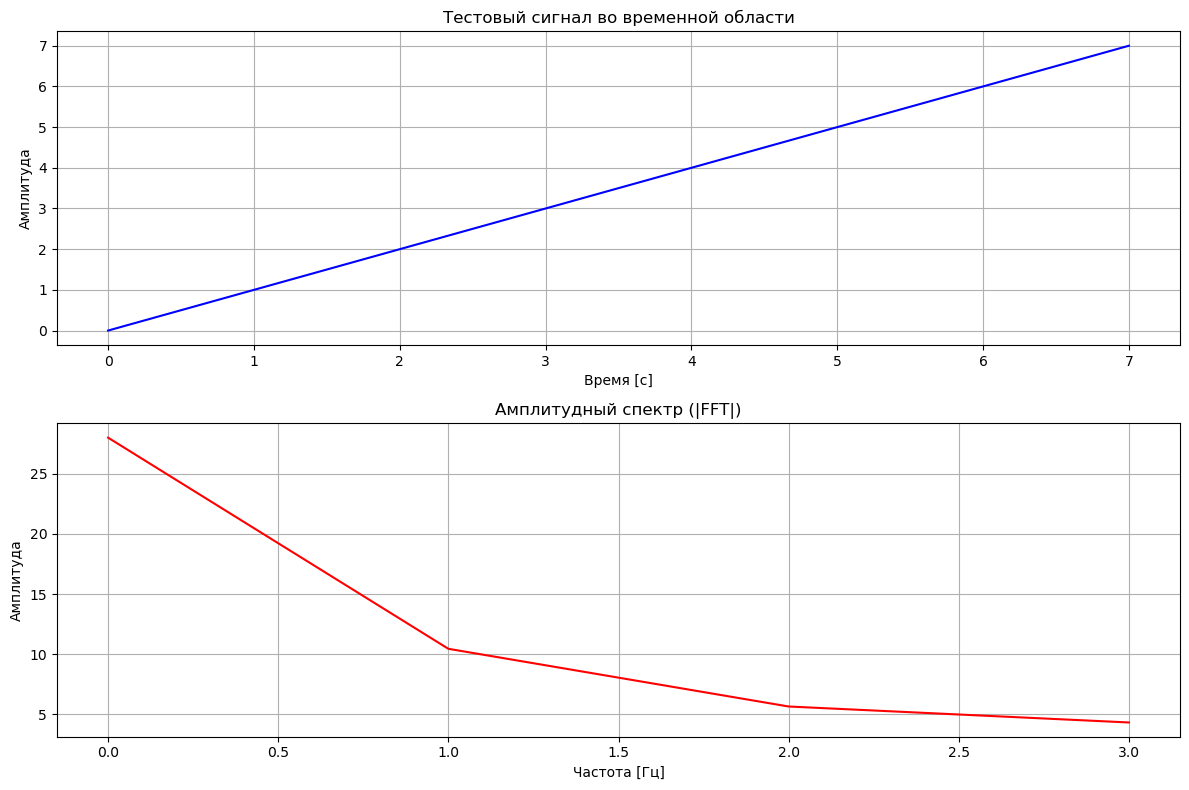

In [1]:
import math
import matplotlib.pyplot as plt

def fft_basic_style(rex, imx):
    """
    Реализация быстрого преобразования Фурье (БПФ) по алгоритму из программы на BASIC.
    Модифицирует входные списки rex и imx на месте.
    """
    N = len(rex)
    if N & (N - 1) != 0:
        raise ValueError("Длина сигнала должна быть степенью двойки!")

    PI = math.pi
    NM1 = N - 1
    ND2 = N // 2
    M = int(math.log2(N))

    # Бит-реверсная перестановка
    J = ND2
    
    for I in range(1, N - 1):
        # if I >= J: 
            # print("+++++")
            # print("I = " + str(I) + "     J = " + str(J) + "   переворота нет")
            # print("+++++")
        if I < J:
            # Обмен rex[I] <-> rex[J], imx[I] <-> imx[J]
            # print("rex = " + str(rex))
            rex[I], rex[J] = rex[J], rex[I]
            imx[I], imx[J] = imx[J], imx[I]
            # print("rex = " + str(rex))
            # print("I = " + str(I) + "     J = " + str(J))
        K = ND2
        # print("I = " + str(I))
        # print("N = " + str(N))
        # print("rex[I] = " + str(rex[I]))
        # print("rex[J] = " + str(rex[J]))
        # print("J = " + str(J))
        # print("K = " + str(K))
        print("------------------------------------")
        # print("while  J = " + str(J))
        # 111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111
        # print("while____  J = " + str(J))
        # print("while____  K = " + str(K))
        while K <= J:
            # print("while_0  J = " + str(J))
            # print("while_0  K = " + str(K))
            J -= K
            # print("while_1  J -= K = " + str(J))
            K //= 2
            # print("while_2  K //= 2 = " + str(K))
        J += K
        # print("while_3  J += K = " + str(J))
        # print("while  J = " + str(J))
    
    print("rex = " + str(rex))
    # Основной цикл БПФ
    for L in range(1, M + 1):
        LE = 2 ** L
        LE2 = LE // 2
        UR = 1.0
        UI = 0.0
        SR = math.cos(PI / LE2)
        SI = -math.sin(PI / LE2)
        print("------------------------------------")
        print("------------------------------------")
        print("ур 1____. L = " + str(L))
        print("LE = 2 ** L = " + str(LE) + "LE2 = LE // 2 " + str(LE2) + "SR =  " + str(SR) + "SI =  " + str(SI))
        for J in range(1, LE2 + 1):
            JM1 = J - 1
            print("ур 2____. L = " + str(J))
            print("JM1 = J - 1 = " + str(JM1))
            for I in range(JM1, N, LE):
                IP = I + LE2
                TR = rex[IP] * UR - imx[IP] * UI
                TI = rex[IP] * UI + imx[IP] * UR
                rex[IP] = rex[I] - TR
                imx[IP] = imx[I] - TI
                rex[I] = rex[I] + TR
                imx[I] = imx[I] + TI
                print("ур 3____. L = " + str(I))
                print("IP = " + str(IP))
                print("TR = " + str(TR))
                print("TI = " + str(TI))
                print("rex[IP] = " + str(rex[IP]))
                print("imx[IP] = " + str(imx[IP]))
                print("rex[I] = " + str(rex[I]))
                print("imx[I] = " + str(imx[I]))
            # Обновление поворачивающего множителя
            TR = UR
            UR = TR * SR - UI * SI
            UI = TR * SI + UI * SR
            print("TR = " + str(TR))
            print("UR = " + str(UR))
            print("UI = " + str(UI))
def generate_test_signal(N, fs=1000):
    """
    Генерация тестового сигнала: сумма двух синусов.
    N — длина сигнала (должна быть степенью 2)
    fs — частота дискретизации (Гц)
    """
    t = [i / fs for i in range(N)]
    # Пример: 50 Гц и 120 Гц
    signal = [math.sin(2 * math.pi * 1 * ti) + 0.5 * math.sin(2 * math.pi * 0 * ti) for ti in t]
    return signal, t

def plot_signal_and_spectrum(signal, t, rex_fft, imx_fft, fs):
    """
    Построение графиков сигнала и амплитудного спектра.
    """
    N = len(signal)
    # Амплитудный спектр
    magnitude = [math.sqrt(rex_fft[i]**2 + imx_fft[i]**2) for i in range(N)]

    # Только первая половина спектра (из-за симметрии для вещественного сигнала)
    freqs = [fs * i / N for i in range(N // 2)]

    plt.figure(figsize=(12, 8))

    # Сигнал во времени
    plt.subplot(2, 1, 1)
    plt.plot(t, signal, 'b')
    plt.title('Тестовый сигнал во временной области')
    plt.xlabel('Время [с]')
    plt.ylabel('Амплитуда')
    plt.grid(True)

    # Амплитудный спектр
    plt.subplot(2, 1, 2)
    plt.plot(freqs, magnitude[:N//2], 'r')
    plt.title('Амплитудный спектр (|FFT|)')
    plt.xlabel('Частота [Гц]')
    plt.ylabel('Амплитуда')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# -----------------------------
# Основная программа
# -----------------------------
if __name__ == "__main__":
    N = 8  # Длина сигнала (должна быть степенью 2)
    fs = 8  # Частота дискретизации, Гц

    # Генерация тестового сигнала
    # signal, t = generate_test_signal(N, fs)
    # signal = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
    # t = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
    signal = [0,1,2,3,4,5,6,7]
    t = [0,1,2,3,4,5,6,7]
    # Подготовка массивов для БПФ
    rex = signal[:]          # действительная часть = сигнал
    imx = [0.0] * N          # мнимая часть = 0 (сигнал вещественный)

    # Выполнение БПФ
    fft_basic_style(rex, imx)

    # Построение графиков
    plot_signal_and_spectrum(signal, t, rex, imx, fs)

In [10]:
import math

def bit_reverse_value(n, num_bits):
    """
    Вычисляет бит-реверсное значение числа
    
    Параметры:
    n - исходное число
    num_bits - количество бит для представления
    
    Возвращает:
    reversed_n - число с обратным порядком бит
    """
    reversed_n = 0
    for i in range(num_bits):
        # Сдвигаем результат влево и добавляем младший бит n
        reversed_n = (reversed_n << 1) | (n & 1)
        # Сдвигаем n вправо
        n >>= 1
    return reversed_n

def detailed_bit_reverse_sort(x):
    """
    Детализированная версия алгоритма с пошаговым выводом
    """
    N = len(x)
    m = int(math.log2(N))
    
    print(f"Размер массива: N = {N} = 2^{m}")
    print(f"Исходный массив: {x}")
    print("\nПроцесс перестановки:")
    
    x_sorted = x.copy()
    
    for i in range(N):
        # Вычисляем бит-реверсный индекс
        j = bit_reverse_value(i, m)
        
        # Выводим информацию о текущей итерации
        print(f"i = {i} (бинарно: {i:0{m}b}) -> j = {j} (бинарно: {j:0{m}b})")
        
        if i < j:
            print(f"  Меняем местами x[{i}] = {x_sorted[i]} и x[{j}] = {x_sorted[j]}")
            x_sorted[i], x_sorted[j] = x_sorted[j], x_sorted[i]
            print(f"  Промежуточный результат: {x_sorted}")
        else:
            print(f"  Пропускаем (i >= j)")
    
    return x_sorted

def visualize_bit_reverse_process(N=8):
    """
    Визуализация процесса бит-реверсной сортировки
    """
    # Создаем тестовый массив [0, 1, 2, ..., N-1]
    x = list(range(N))
    m = int(math.log2(N))
    
    print("=" * 50)
    print("ВИЗУАЛИЗАЦИЯ БИТ-РЕВЕРСНОЙ СОРТИРОВКИ")
    print("=" * 50)
    
    # Создаем таблицу для наглядности
    print("\nТаблица преобразования индексов:")
    print("Исходный индекс | Бинарно | Реверс бинарно | Реверс индекс")
    print("-" * 65)
    
    for i in range(N):
        binary_i = format(i, f'0{m}b')
        reversed_i = bit_reverse_value(i, m)
        binary_reversed = format(reversed_i, f'0{m}b')
        print(f"{i:^14} | {binary_i:^7} | {binary_reversed:^14} | {reversed_i:^13}")
    
    # Выполняем сортировку с подробным выводом
    print(f"\nПроцесс сортировки массива: {x}")
    result = detailed_bit_reverse_sort(x)
    print(f"\nФинальный результат: {result}")

# Запускаем визуализацию
visualize_bit_reverse_process(8)

ВИЗУАЛИЗАЦИЯ БИТ-РЕВЕРСНОЙ СОРТИРОВКИ

Таблица преобразования индексов:
Исходный индекс | Бинарно | Реверс бинарно | Реверс индекс
-----------------------------------------------------------------
      0        |   000   |      000       |       0      
      1        |   001   |      100       |       4      
      2        |   010   |      010       |       2      
      3        |   011   |      110       |       6      
      4        |   100   |      001       |       1      
      5        |   101   |      101       |       5      
      6        |   110   |      011       |       3      
      7        |   111   |      111       |       7      

Процесс сортировки массива: [0, 1, 2, 3, 4, 5, 6, 7]
Размер массива: N = 8 = 2^3
Исходный массив: [0, 1, 2, 3, 4, 5, 6, 7]

Процесс перестановки:
i = 0 (бинарно: 000) -> j = 0 (бинарно: 000)
  Пропускаем (i >= j)
i = 1 (бинарно: 001) -> j = 4 (бинарно: 100)
  Меняем местами x[1] = 1 и x[4] = 4
  Промежуточный результат: [0, 4, 2, 3, 1, 

БПФ для действительных сигналов - визуализация


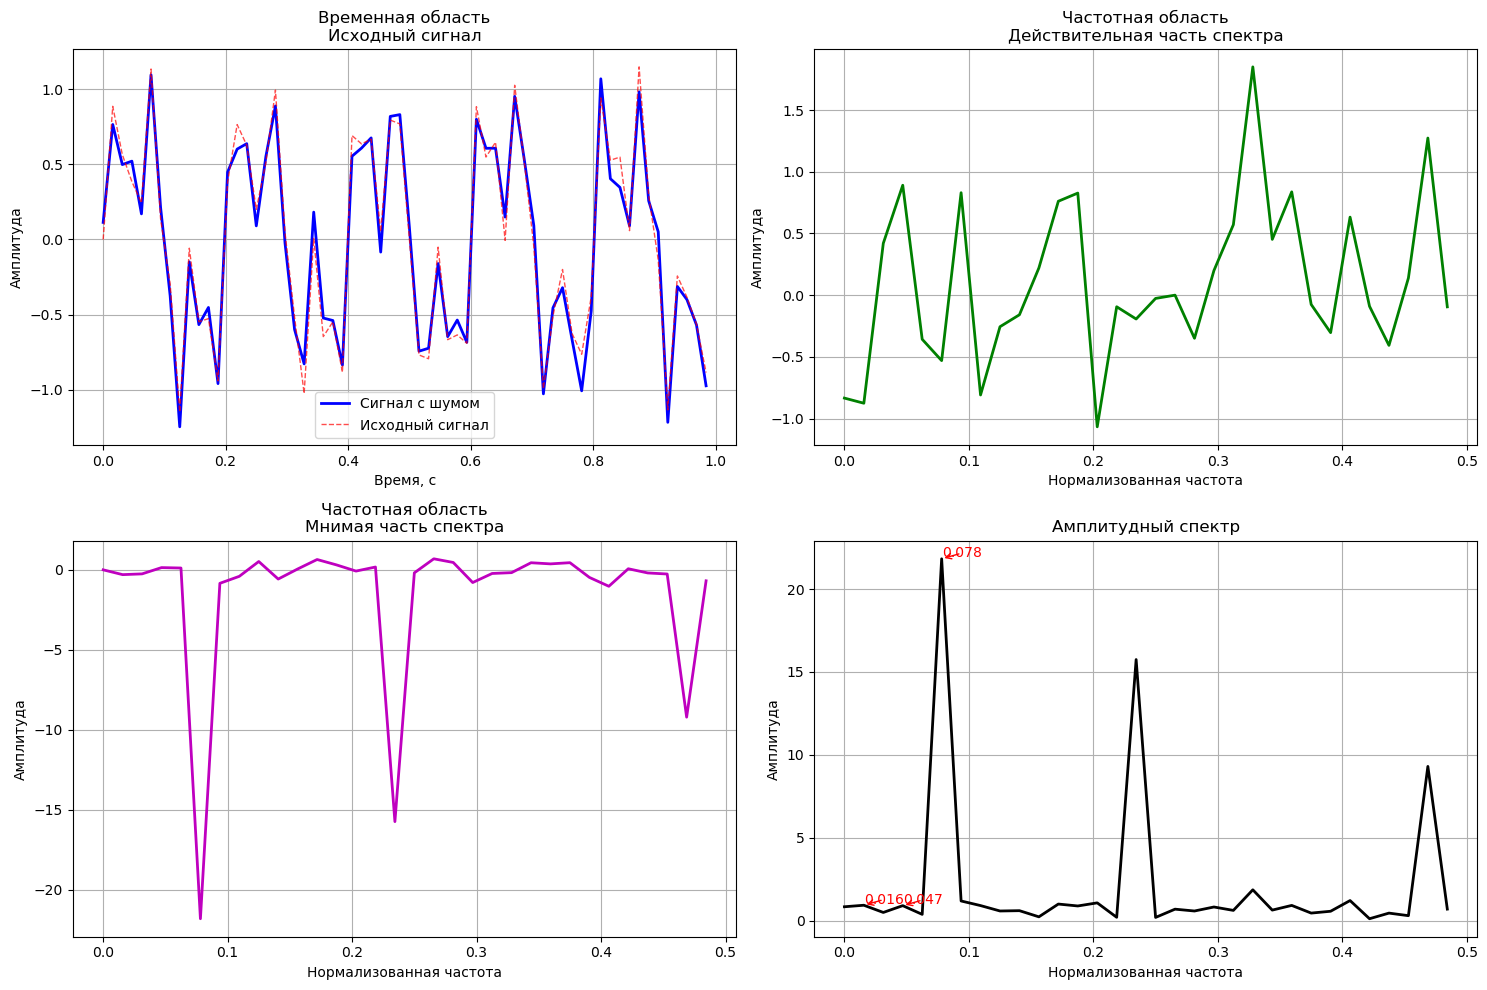

Обнаруженные частотные компоненты:
Пик 1: частота = 0.016, амплитуда = 0.926
Пик 2: частота = 0.047, амплитуда = 0.901
Пик 3: частота = 0.078, амплитуда = 21.828


In [11]:
import math
import matplotlib.pyplot as plt
import numpy as np

def bit_reverse_value(n, num_bits):
    """Вычисляет бит-реверсное значение числа"""
    reversed_n = 0
    for i in range(num_bits):
        reversed_n = (reversed_n << 1) | (n & 1)
        n >>= 1
    return reversed_n

def complex_fft(rex, imx, n):
    """БПФ для комплексных сигналов (Программа 12.3)"""
    # Бит-реверсная перестановка
    m = int(math.log2(n))
    for i in range(n):
        j = bit_reverse_value(i, m)
        if i < j:
            rex[i], rex[j] = rex[j], rex[i]
            imx[i], imx[j] = imx[j], imx[i]
    
    # Основной алгоритм БПФ
    l = int(math.log2(n))
    for stage in range(1, l + 1):
        le = 2 ** stage
        le2 = le // 2
        ur = 1.0
        ui = 0.0
        sr = math.cos(math.pi / le2)
        si = -math.sin(math.pi / le2)
        
        for j in range(le2):
            for i in range(j, n, le):
                ip = i + le2
                tr = rex[ip] * ur - imx[ip] * ui
                ti = rex[ip] * ui + imx[ip] * ur
                rex[ip] = rex[i] - tr
                imx[ip] = imx[i] - ti
                rex[i] = rex[i] + tr
                imx[i] = imx[i] + ti
            
            tr = ur
            ur = tr * sr - ui * si
            ui = tr * si + ui * sr
    
    return rex, imx

def fft_real_signal(original_rex):
    """БПФ для действительных сигналов (Программа 12.6)"""
    n = len(original_rex)
    rex = original_rex.copy()
    imx = [0.0] * n
    
    # Разделение четных и нечетных отсчетов
    nh = n // 2 - 1
    temp_rex = [0.0] * n
    temp_imx = [0.0] * n
    
    for i in range(nh + 1):
        temp_rex[i] = rex[2 * i]
        temp_imx[i] = rex[2 * i + 1]
    
    # Вычисление БПФ порядка n/2
    n_half = n // 2
    temp_rex, temp_imx = complex_fft(temp_rex[:n_half], temp_imx[:n_half], n_half)
    
    # Восстановление размера массивов
    rex = temp_rex + [0.0] * (n - n_half)
    imx = temp_imx + [0.0] * (n - n_half)
    
    # Разложение на четные и нечетные элементы в частотной области
    nm1 = n - 1
    nd2 = n // 2
    n4 = n // 4 - 1
    
    for i in range(1, n4 + 1):
        im = nd2 - i
        ip2 = i + nd2
        ipm = im + nd2
        
        rex[ip2] = (imx[i] + imx[im]) / 2
        rex[ipm] = rex[ip2]
        imx[ip2] = -(rex[i] - rex[im]) / 2
        imx[ipm] = -imx[ip2]
        rex[i] = (rex[i] + rex[im]) / 2
        rex[im] = rex[i]
        imx[i] = (imx[i] - imx[im]) / 2
        imx[im] = -imx[i]
    
    rex[3 * n // 4] = imx[n // 4]
    rex[nd2] = imx[0]
    imx[3 * n // 4] = 0
    imx[nd2] = 0
    imx[n // 4] = 0
    imx[0] = 0
    
    # Завершение последнего этапа БПФ
    PI = 3.14159265
    l = int(math.log2(n))
    le = 2 ** l
    le2 = le // 2
    ur = 1.0
    ui = 0.0
    sr = math.cos(PI / le2)
    si = -math.sin(PI / le2)
    
    for j in range(1, le2 + 1):
        jm1 = j - 1
        for i in range(jm1, nm1 + 1, le):
            ip = i + le2
            tr = rex[ip] * ur - imx[ip] * ui
            ti = rex[ip] * ui + imx[ip] * ur
            rex[ip] = rex[i] - tr
            imx[ip] = imx[i] - ti
            rex[i] = rex[i] + tr
            imx[i] = imx[i] + ti
        
        tr = ur
        ur = tr * sr - ui * si
        ui = tr * si + ui * sr
    
    return rex, imx

def visualize_fft_real_signal():
    """Визуализация БПФ для действительных сигналов"""
    # Создаем тестовый сигнал
    n = 64
    t = np.linspace(0, 1, n, endpoint=False)
    
    # Сигнал: сумма трех синусоид разных частот
    f1, f2, f3 = 5, 15, 30
    signal = (0.7 * np.sin(2 * np.pi * f1 * t) + 
              0.5 * np.sin(2 * np.pi * f2 * t) + 
              0.3 * np.sin(2 * np.pi * f3 * t))
    
    # Добавляем немного шума
    noise = 0.1 * np.random.normal(0, 1, n)
    signal_with_noise = signal + noise
    
    # Выполняем БПФ
    rex_orig = signal_with_noise.tolist()
    rex_result, imx_result = fft_real_signal(rex_orig)
    
    # Вычисляем амплитудный спектр
    amplitude_spectrum = [math.sqrt(rex_result[k]**2 + imx_result[k]**2) for k in range(n)]
    frequencies = [k / n for k in range(n)]  # Нормализованные частоты
    
    # Визуализация
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Исходный сигнал
    ax1.plot(t, signal_with_noise, 'b-', linewidth=2, label='Сигнал с шумом')
    ax1.plot(t, signal, 'r--', linewidth=1, alpha=0.7, label='Исходный сигнал')
    ax1.set_title('Временная область\nИсходный сигнал')
    ax1.set_xlabel('Время, с')
    ax1.set_ylabel('Амплитуда')
    ax1.legend()
    ax1.grid(True)
    
    # Действительная часть спектра
    ax2.plot(frequencies[:n//2], rex_result[:n//2], 'g-', linewidth=2)
    ax2.set_title('Частотная область\nДействительная часть спектра')
    ax2.set_xlabel('Нормализованная частота')
    ax2.set_ylabel('Амплитуда')
    ax2.grid(True)
    
    # Мнимая часть спектра
    ax3.plot(frequencies[:n//2], imx_result[:n//2], 'm-', linewidth=2)
    ax3.set_title('Частотная область\nМнимая часть спектра')
    ax3.set_xlabel('Нормализованная частота')
    ax3.set_ylabel('Амплитуда')
    ax3.grid(True)
    
    # Амплитудный спектр
    ax4.plot(frequencies[:n//2], amplitude_spectrum[:n//2], 'k-', linewidth=2)
    ax4.set_title('Амплитудный спектр')
    ax4.set_xlabel('Нормализованная частота')
    ax4.set_ylabel('Амплитуда')
    ax4.grid(True)
    
    # Отмечаем пики на амплитудном спектре
    peaks = []
    for i in range(1, n//2 - 1):
        if (amplitude_spectrum[i] > amplitude_spectrum[i-1] and 
            amplitude_spectrum[i] > amplitude_spectrum[i+1] and 
            amplitude_spectrum[i] > 0.1):
            peaks.append((frequencies[i], amplitude_spectrum[i]))
    
    for freq, amp in peaks[:3]:  # Показываем первые 3 пика
        ax4.annotate(f'{freq:.3f}', xy=(freq, amp), xytext=(freq, amp + 0.1),
                    arrowprops=dict(arrowstyle='->', color='red'),
                    fontsize=10, color='red')
    
    plt.tight_layout()
    plt.show()
    
    # Выводим информацию о пиках
    print("Обнаруженные частотные компоненты:")
    for i, (freq, amp) in enumerate(peaks[:3]):
        actual_freq = freq  # Для нормализованных частот
        print(f"Пик {i+1}: частота = {actual_freq:.3f}, амплитуда = {amp:.3f}")
    
    return rex_result, imx_result, amplitude_spectrum

# Запускаем визуализацию
print("БПФ для действительных сигналов - визуализация")
print("=" * 50)
rex, imx, amp_spectrum = visualize_fft_real_signal()